# PS Potentials


## Overall notes about potentials

### Pair potentials
If potentials act between the same group (e.g., through a Helfand potential where $U = \frac{\kappa}{2\rho_0} \int d{\mathbf r} \int d\mathbf{r}' \, \rho_+(\mathbf{r}) \, u_G(\mathbf{r}-\mathbf{r}') \, \rho_+(\mathbf{r}')$) with $u_G$ a unit Gaussian, then the force is accumulated twice in the ps_potentials.cu calcForces() routine. If such a 'self'-interacting potential is used, take care when defining the prefactor such that it includes the factor of 1/2.

### Smearing and pair potentials

While full details can be found in the literature (Koski et al. J. Chem. Phys. 2013; Villet et al., J. Chem. Phys. 2014), some of the 'unusual' pair potentials included herein derive from the smearing functions used in field-theoretic simulations (FTS), a brief explainer is provided here. The microscopic density can be written as $\hat \rho_I(\mathbf r) = \sum_i \delta(\mathbf r - \mathbf r_i)$, where the particle centers are marked using Dirac delta functions. If the 'mass' of the particle is instead spread out over a finite range described by the function $h_I(\mathbf r)$, then the 'smeared' particle density can be written as  
$
\breve \rho_I(\mathbf r) = \sum_i h_I(\mathbf r - \mathbf r_i) = \int d\mathbf r' \; h_I(\mathbf r - \mathbf r') \, \hat \rho(\mathbf r') = [h_I \ast \hat\rho_I](\mathbf r)
$  
where the last equality introduces our short-hand notation for a convolution integral.

Many field-theoretic simulations use purely local, Delta function interaction potentials of the form $u(r) = A \, \delta(r)$, where $A$ is the amplitude of the potential. For a model that uses such a potential but *smeared* particle densities, the potential energy would be  
$
\begin{alignat}{1}
    \beta U &= A \int d\mathbf r \int d\mathbf r'\; \breve\rho(\mathbf r) \, \delta(|\mathbf r - \mathbf r'|) \, \breve\rho(\mathbf r')
    \\
    &= \int d\mathbf r \int d\mathbf r'\; \hat \rho(\mathbf r) \, u_{IJ}(|\mathbf r - \mathbf r'|) \, \hat \rho(\mathbf r')
\end{alignat}
$  
where in the second line we have restored the delta function densities $\hat \rho_I, \hat \rho_J$ but now have a non-local pair potential $u_{IJ}(r) = A [h_I \ast h_J](r)$. 

To preserve the equivalence between FTS and particle simulations (PS), we often use pair potentials derived from the smearing functions commonly used in FTS. For the ubiquitous Gaussian-smearing function, one finds $u_{IJ}(r) = A\, \left( \frac{1}{2\pi \sigma^2} \right)^{3/2} e^{-r^2/2(\sigma_I^2 + \sigma_J^2)}$.

The two other primary potentials we have implemented derive from our work with field-theoretic simulations of polymer nanocomposites where the nanoparticles are smeared with a error function as $h_{N}(\mathbf r) = \frac{\rho_0}{2} \textrm{erfc}\left( \frac{|\mathbf r| - R_P}{\xi}\right)$, where $\rho_0$ is the bulk density in the center of the nanoparticle, $R_P$ is the nanoparticle radius, and $\xi$ is the breadth of the particle interface where the density of the particle transitions from $\rho_0$ to 0. The `erf2` potential described below represents the convolution of two nanoparticle smearing functions with potentially two distinct particle sizes $R_P$ and interfacial widths $\xi$, which is meant to regularize but still capture excluded volume interactions between the particles. Similarly, the `erfG` potential is the convolution of a nanoparticle $h(r)$ with a Gaussian and is used to capture interactions between NPs and polymer monomers.


## Gaussian potential
`potential gaussian [group I] [group J] [prefactor float] [std deviation float]`

Imposes a Gaussian non-bonded potential between groups I and J of the form  
$ U_{nb} = \int d\mathbf{r} \int d\mathbf{r}' \, \rho_I(\mathbf{r}) \, u_G(|\mathbf{r} - \mathbf{r}'|) \, \rho_J(\mathbf{r}')$  
with Gaussian potential $u_G(r) = A \left( \frac{1}{2\pi \sigma^2} \right)^{\mathbb{D}/2} e^{-r^2/2\sigma^2}$. The prefactor is the value of $A$, and the standard deviation $\sigma$ controls the range of the potential. This potential has become a common way to 'smear' the delta functions that are commonly used in SCFT calculations to regularize the models, and the non-local potential gives rise to (weak) liquid-like correlations in the fluid. 

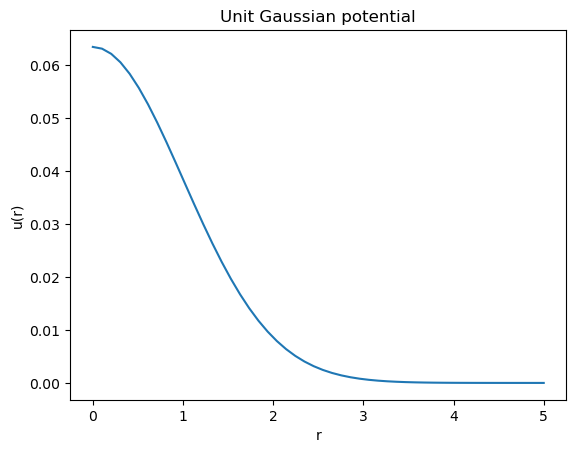

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf

r = np.linspace(0, 5.0)
u = (2.0*3.14159*1.0)**-1.5 * np.exp(-r**2 / 2)

plt.figure(1)
plt.plot(r,u)
plt.title('Unit Gaussian potential')
plt.ylabel('u(r)')
plt.xlabel('r')
plt.show()



## Charges and electrostatics
`potential charges [Bjerrum float] [sigmaq float]`

Enables calculation of electrostatic interactions using floats $l_B$, the Bjerrum length, and $\sigma_q$ the charge smearing length.

Charge interactions assume the charges are distributed over a unit Gaussian centered at the particle middle, so that the charge density is taken as $\breve \rho_c(\mathbf r) = \sum_i q_i \, h_G(\mathbf r - \mathbf r_i)$, with $h_G(\mathbf r)$ a unit Gaussian in the appropriate number of dimensions with standard deviation $\sigma_q$.  The electrostatic interaction potential and forces are then computed by solving Poisson's equation,  
$$
\nabla^2 \phi = -4\pi l_B \breve\rho_c,
$$  
which is readily solved using Fourier transforms. Here, $\phi(\mathbf r)$ is the electrostatic potential, $\mathbf{E} = -\nabla \phi$ is the electric field, and $l_B$ is the Bjerrum length. The electrostatic energy is then computed as
$$
U_{q} = \frac 1 2 \int d\mathbf {r} \; \breve \rho(\mathbf r) \, \phi(\mathbf r).
$$


Note that the above implementation is *exactly* the same as the k-space part of the common Ewald summation used in particle simulations. The effective pair potential is regularized as $r\rightarrow 0^+$ and is compared to the standard Coulomb potential in the figure below.




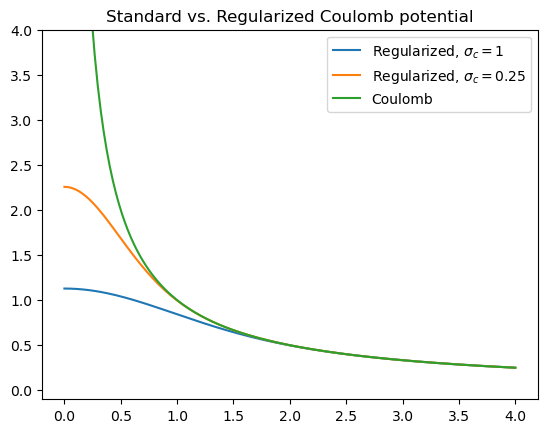

In [ ]:
r = np.linspace(0.00001,4, 150)
sig1 = 1.0
sig2 = 0.5

plt.figure(4)
plt.plot(r, erf(r/sig1)/r, label='Regularized, $\sigma_c = 1$')
plt.plot(r, erf(r/sig2)/r, label='Regularized, $\sigma_c=0.25$')
plt.plot(r,1/r, label='Coulomb')
plt.ylim([-0.1,4])
plt.title('Standard vs. Regularized Coulomb potential')
plt.legend()
plt.show()


### Implementation notes
The Poisson equation is solved in Fourier space, where the convolution of the point charge density with $h_G(\mathbf r)$ becomes a product, $\phi_k = \frac{4 \pi l_B}{k^2} \rho_c(k) \,  h_G(k)$ for $|k| \neq 0$ and with $\rho_c(k)$ the Fourier transform of the point charge density. Since evaluating $U_q$ requires multiplying again by $\breve \rho_c(k)$, the smeared charge density, $U_q$ is precomputed with $h_G(k)^2$. Similar rationale applies for mapping the force back to the particles, 
$$
\mathbf f_i = \int d\mathbf r \; h_G(\mathbf r- \mathbf r_i) \, \mathbf E(\mathbf r),
$$
so this step of Gaussian smearing is also contained in the precomputed factor of $h_G(k)^2$. 

The pre-computed k-space terms are invariant during the simulations that do not change (assuming constant box dimensions), and they are computed during initialization as
$$
\psi(k) = \frac{4\pi l_B}{k^2} \, h_G(k)^2    \;\;\; \forall \; |k| \neq 0,
$$
and
$$
-\mathbf \nabla \psi(r) = \mathcal{F}^{-1}[-i \mathbf k \psi(k)].
$$

If $\hat \rho_c(k)$ is the Fourier transform of the point particle density, then the operations to compute the energy are to compute
$$
g(k) &= \psi(k) \, \hat\rho_c(k),  
$$
$$
g(\mathbf r) = \mathcal{F}^{-1}[g(k)],  
$$
and
$$
U_{q} = \frac{1}{2} \int d\mathbf r \; g(\mathbf r) \, \hat \rho_c(\mathbf r).  
$$
Similarly, the force on particle *i* is given by  
$$
\mathbf f_i(\mathbf r) = q_i \int d\mathbf r \, \left[ -\mathbf \nabla g(\mathbf r) \right] \delta (\mathbf r - \mathbf r_i) .  
$$
Note $\psi(r) \neq \phi(r)$ due to the extra convolution with $h_G(r)$ (similar for the electric field, $\mathbf E(r)$).

These initialization steps are taken in `ps_potentialCharges.cu` in the function `NBCharge::initializePotential()`.

### Notes

The old version 1 of the code base did not have the extra convolution included, so the new code must be run with $\sigma_{c,new} = \sigma_{c,old}/\sqrt{2}$ to obtain matching energies.

## Maier-Saupe potential (in progress)
`potential maier [group I] [group I] [prefactor float] [sigma float] [lc input filename] `

Imposes a Maier-Saupe orientation potential between particles in group I. The potential is non-local using a unit Gaussian and with amplitude `prefactor` and standard deviation `sigma`.

The total potential energy is given by the form adopted from Pryamitsyn and Ganesan  
%{cite}`pryamitsyn2004self`  
$$
\beta U_{ms} = -\frac{A_0}{2} \int d\mathbf{r} \int d\mathbf{r}' \, \mathbf{S}(\mathbf{r}):\mathbf{S}(\mathbf{r}')  \; u_G(|\mathbf{r} - \mathbf{r}'|)  
$$  
Note the prefactor is *negative*, so the typical use case will provide a positive prefactor ($A_0 > 0$) to promote alignment of the molecules in group $I$.

The tensor field $\mathbf{S}(\mathbf{r})$ is constructed from the particle positions as  
$\mathbf{S}(\mathbf{r}) = \sum_{i \in I} \mathbf{S}_i \, \delta(\mathbf{r} - \mathbf{r}_i)$  
where $\mathbf{S}_i = (\mathbf{u}_i \mathbf u_i - \frac{\mathcal{I}}{\mathbb{D}})$ is a rank 2 tensor that defines the orientation of the molecules involved, $\mathbf{u}_i = \mathbf{r}_{ij} / |\mathbf{r}_{ij}|$ is the unit vector defining the orientation vector associated with particle $i$, and $\mathcal{I}$ is an identity tensor with $\mathbb{D}$ the dimensionality of the system. The orientation vector depends on the position of a 'partner' particle $j$, which is defined during initialization in `lc.input`.

### Implementation notes

The force is obtained through explicit differentiation with respect to the positions of particles $i$ and $j$, similar to the isotropic pair potentials, though there are two significant contributions to the force for the Maier-Saupe form. First, there is the $\nabla u_G$ contribution $\mathbf{f}_{i,1}$,  
$$
\mathbf{f}_{i,1}(\mathbf{r}) = A_0 \int d\mathbf{r}' \, \delta(\mathbf{r} - \mathbf{r}_i)\,  \mathbf{S}_i : \mathbf{S}(\mathbf{r}') \nabla u_G(\mathbf{r} - \mathbf{r}').  
$$  
This contribution is mapped onto particle coordinates using a spline particle-to-mesh scheme as per usual.  

The second contribution arises from $\partial \mathbf{S}(r) / \partial \mathbf{r}_i$ and is given by  
$$  
\mathbf{f}_{i,2}(\mathbf{r}) = A_0 \int d\mathbf{r}' \, \delta(\mathbf{r} - \mathbf{r}_i)\,  \left[ (\mathcal{I}\mathbf{u}_i + \mathbf{u}_i \mathcal{I}) \cdot \frac{\partial \mathbf{u}_{i}}{\partial \mathbf{r}_i} \right]: \mathbf{S}(\mathbf{r}') u_G(\mathbf{r} - \mathbf{r}')  
$$
This can be written with less ambiguity in indicial notation as  
$$
f_{i,2,\alpha}(\mathbf r) = A_0 \int d\mathbf{r}'\, \delta(\mathbf{r}-\mathbf{r}_i)\left(\frac{\partial u_{i,\mu}}{\partial r_{i,\alpha}} u_{i,\nu} + u_{i,\mu} \frac{\partial u_{i,\nu}}{\partial r_{i,\alpha}}\right) S_{\mu\nu}(\mathbf{r}')\, u_G(\mathbf{r}-\mathbf{r}'),  
$$  
where the sum over repeated indices $\mu$ and $\nu$ is implied. The total force on particle *i* from this potential is then $\mathbf{f}_i = \mathbf{f}_{i,1} + \mathbf{f}_{i,2}$, and the contribution to the force on particle $j$ is $\mathbf f_j = -\mathbf f_{i,2}$.


## erf2 potential (in progress)
`potential erf2 [group I] [group J] [prefactor float] [Rp1 float] [xi1 float] [Rp2 float] [xi2 float]`

Imposes a non-bonded potential between groups I and J of the form  
$ U_{erf2} = [h_I \ast h_J](\mathbf r)$  
where $h_I(\mathbf r)$ and $h_J(\mathbf r)$ are nanoparticle smearing functions defined as $h_I(\mathbf r) = \frac{\rho_0}{2} \textrm{erfc}\left( \frac{|\mathbf r| - R_I}{\xi_I}\right)$ and $R_I, \xi_I$ are the radius and smearing length of nanoparticle type $I$. 
<!---
A 1D sample of the potential and its form is shown below, and one should note that the potential is *extensive* in the nanoparticle volume. Care should be taken in the choice of the amplitude $A$ to provide sufficiently strong excluded volume effects and not so large that numerical integration becomes unstable.
-->

Each $h_I$ is defined in Fourier space as a convolution of a spherical step function with a Gaussian, $h(k) = \frac{\rho_0}{2} e^{-k^2 \xi_I^2/2} \, S_I(k)$ with $S_I(k) = \frac{4\pi}{k^3} \left[ \sin(R_{pI}k) - R_{pI}k \cos(R_{pI}k)\right]$.

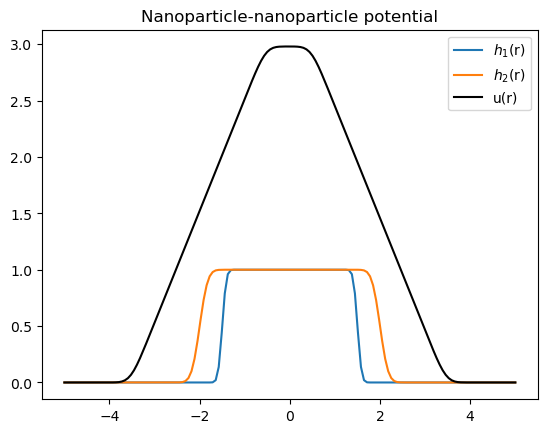

In [ ]:
from scipy.special import erf
Rp1 = 1.5;
xi1 = 0.1;
Rp2 = 2.0;
xi2 = 0.2;
A = 1.0;
rho0 = 1.0;
M = 150;
V = 10.

r = np.linspace(-V/2, V/2, M)
h1 = rho0/2.0*(1.0-erf((np.abs(r)-Rp1)/xi1))
h2 = rho0/2.0*(1.0-erf((np.abs(r)-Rp2)/xi2))

hft1 = np.fft.fft(h1);
hft2 = np.fft.fft(h2);
uft = hft1*hft2
u = np.fft.ifft(uft) * V / M
u = np.concatenate((u[int(M/2):M], u[0:int(M/2)]))

plt.figure(2)
plt.title('Nanoparticle-nanoparticle potential')
plt.plot(r,h1,label='$h_1$(r)')
plt.plot(r,h2,'-', label='$h_2$(r)')
plt.plot(r, np.real(u), 'k', label='u(r)')
plt.legend()
plt.show()

## erfG potential (in progress)
`potential erfG [group I] [group J] [prefactor float] [Rp float] [xi float] [sigma float]`

Imposes a non-bonded potential between groups I and J of the form  
$ U_{erfG} = [h_I \ast h_J](\mathbf r)$  
where $h_I(\mathbf r)$ is a nanoparticle smearing function defined as $h_I(\mathbf r) = \frac{\rho_0}{2} \textrm{erfc}\left( \frac{|\mathbf r| - R_I}{\xi_I}\right)$ and $R_I, \xi_I$ are the radius and smearing length of nanoparticle type $I$, and $h_J$ is a unit Gaussian distribution with variance $\sigma^2$. A 1D sample of the potential and its form is shown below.

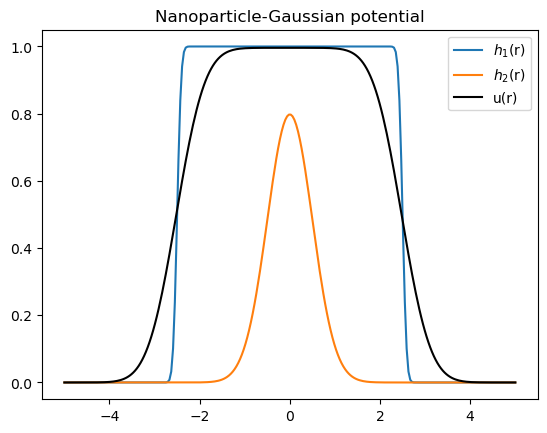

In [ ]:
from scipy.special import erf
Rp = 2.5;
xi = 0.1;
sigma = 0.5;
A = 1.0;
rho0 = 1.0;
M = 250;
V = 10.

r = np.linspace(-V/2, V/2, M)
h1 = rho0/2.0*(1.0-erf((np.abs(r)-Rp)/xi))
h2 = (2*np.pi*sigma**2)**(-0.5)*np.exp(-r**2/2./sigma**2)

hft1 = np.fft.fft(h1);
hft2 = np.fft.fft(h2);
uft = hft1*hft2
u = np.fft.ifft(uft) * V / M
u = np.concatenate((u[int(M/2):M], u[0:int(M/2)]))

plt.figure(3)
plt.title('Nanoparticle-Gaussian potential')
plt.plot(r,h1,label='$h_1$(r)')
plt.plot(r,h2,'-', label='$h_2$(r)')
plt.plot(r, np.real(u), 'k', label='u(r)')
plt.legend()
plt.show()

```{bibliography} ./references.bib
```